# Latihan 7 : Logit Biner
### 1. Import Library

In [ ]:
import pandas as pd 
#import numpy as nps
from sklearn.datasets import make_classification 
from imblearn.over_sampling import RandomOverSampler 
#from imblearn.under_sampling import RandomUnderSampler 
from collections import Counter 
from sklearn.model_selection import train_test_split 
#from sklearn.linear_model import LogisticRegression 
#from sklearn import metrics 
#import seaborn as sn 
import matplotlib.pyplot as plt

### 2. Membuka Dataset

In [39]:
dataset = pd.read_csv("C:\\Users\\faizr\\Documents\\Data-Data Faiz\\File Kuliah dkk\\Semester 2\\Pemodelan Statistik Terapan\\klasifikasi__UKT_komplit.csv") 
dataset.head(10)

,No.,StatusOrtu,Penghasilan,Status_Rumah,JMotor,Jmobil,DayaLis,KIPK
0,1,1,4000000,1,1,0,2,0
1,2,1,2500000,0,1,0,3,0
2,3,1,6000000,1,2,0,2,0
3,4,1,5440500,1,2,0,2,0
4,5,1,10000000,0,1,1,3,0
5,6,1,1000000,0,1,0,3,1
6,7,1,20000000,1,2,1,3,0
7,8,1,15000000,1,1,0,3,0
8,9,4,4000000,1,1,1,3,0
9,10,1,0,1,2,0,1,0


### 3. Statistik Deskriptif

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1707 entries, 0 to 1706
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   No.           1707 non-null   int64
 1   StatusOrtu    1707 non-null   int64
 2   Penghasilan   1707 non-null   int64
 3   Status_Rumah  1707 non-null   int64
 4   JMotor        1707 non-null   int64
 5   Jmobil        1707 non-null   int64
 6   DayaLis       1707 non-null   int64
 7   KIPK          1707 non-null   int64
dtypes: int64(8)
memory usage: 106.8 KB


In [8]:
dataset.describe()

,No.,StatusOrtu,Penghasilan,Status_Rumah,JMotor,Jmobil,DayaLis,KIPK
count,1707.000000,1707.000000,1.707000e+03,1707.000000,1707.000000,1707.000000,1707.000000,1707.000000
mean,854.000000,1.164030,5.195012e+06,0.807264,1.968366,0.357938,2.205038,0.157586
std,492.912771,0.565764,5.552922e+06,0.394563,0.823274,0.541534,0.676276,0.364460
min,1.000000,1.000000,-1.000000e+06,0.000000,0.000000,0.000000,1.000000,0.000000
25%,427.500000,1.000000,2.000000e+06,1.000000,1.000000,0.000000,2.000000,0.000000
50%,854.000000,1.000000,4.000000e+06,1.000000,2.000000,0.000000,2.000000,0.000000
75%,1280.500000,1.000000,6.131916e+06,1.000000,2.000000,1.000000,3.000000,0.000000
max,1707.000000,4.000000,7.300000e+07,1.000000,5.000000,3.000000,3.000000,1.000000


In [42]:
del(dataset["No."]) 
dataset.describe()

,StatusOrtu,Penghasilan,Status_Rumah,JMotor,Jmobil,DayaLis,KIPK
count,1707.000000,1.707000e+03,1707.000000,1707.000000,1707.000000,1707.000000,1707.000000
mean,1.164030,5.195012e+06,0.807264,1.968366,0.357938,2.205038,0.157586
std,0.565764,5.552922e+06,0.394563,0.823274,0.541534,0.676276,0.364460
min,1.000000,-1.000000e+06,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1.000000,2.000000e+06,1.000000,1.000000,0.000000,2.000000,0.000000
50%,1.000000,4.000000e+06,1.000000,2.000000,0.000000,2.000000,0.000000
75%,1.000000,6.131916e+06,1.000000,2.000000,1.000000,3.000000,0.000000
max,4.000000,7.300000e+07,1.000000,5.000000,3.000000,3.000000,1.000000


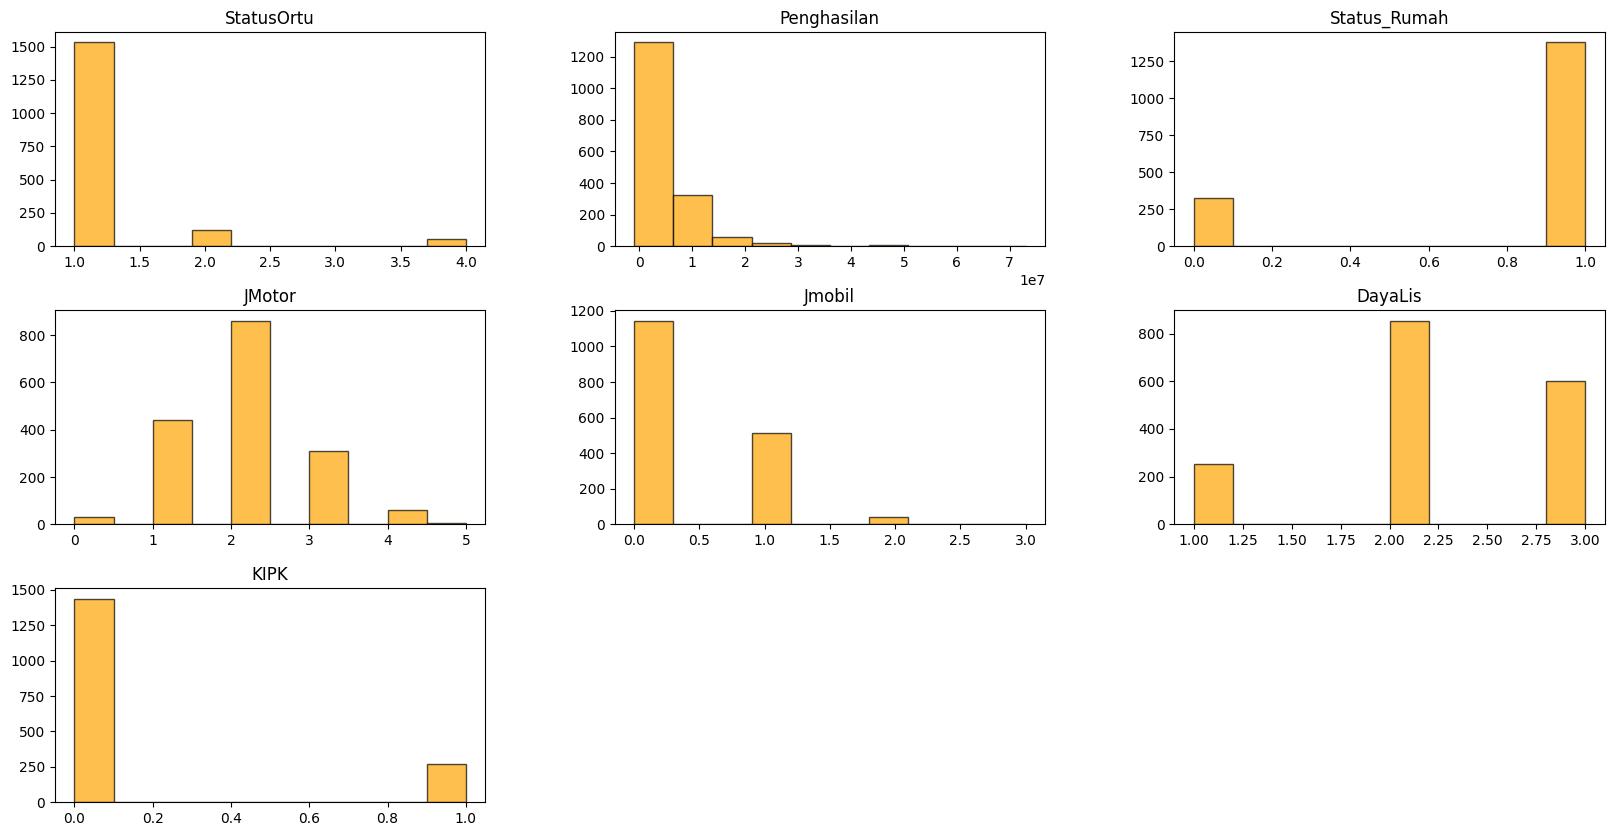

In [43]:
user_data_for_hist = dataset 
user_data_for_hist.hist(figsize=(20,10),alpha = 0.7, color = 'orange',edgecolor ='black',grid=False);

### 4.0 Identifikasi Pelanggaran SRP: Blok Preprocessing

Blok kode preprocessing (slicing fitur, normalisasi, konversi tipe target, split data, dan oversampling) sebelumnya ditulis sebagai kode flat berurutan dalam beberapa cell terpisah tanpa fungsi. Ini melanggar **SRP** karena tanggung jawabnya bercampur: menyiapkan fitur, menyiapkan target, membagi data, dan menyeimbangkan kelas semuanya jadi satu alur tanpa batas yang jelas.

Dipisah menjadi 3 fungsi dengan tanggung jawab tunggal:
- `prepare_features_and_target(dataset)` -> hanya slicing + normalisasi X, konversi tipe y
- `split_data(X, y)` -> hanya membagi data train/test
- `oversample_data(X_train, y_train)` -> hanya melakukan oversampling


In [ ]:
from sklearn.preprocessing import MinMaxScaler


def prepare_features_and_target(dataset):
    """Tanggung jawab tunggal: slicing fitur (X) & target (y), lalu menormalisasi X dan mengonversi tipe y."""
    data_array = dataset.values
    X = data_array[:, 1:6]  # slicing dataframe ke dalam array
    y = data_array[:, 6]
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X)
    y = y.astype("int")
    return X, y


def split_data(X, y, test_size=0.2, random_state=2):
    """Tanggung jawab tunggal: membagi data menjadi train dan test."""
    return train_test_split(X, y, test_size=test_size, random_state=random_state)


def oversample_data(X_train, y_train):
    """Tanggung jawab tunggal: melakukan oversampling pada data training."""
    ros = RandomOverSampler()
    return ros.fit_resample(X_train, y_train)


### 4.0.1 Penyederhanaan KISS pada Blok Preprocessing dan ROC

Setelah ditinjau ulang, ditemukan dua hal yang bisa disederhanakan tanpa mengubah hasil program:
1. Variabel `array` pada `prepare_features_and_target()` diganti menjadi `data_array` agar lebih jelas maksudnya (bukan sekadar tipe data array, tapi representasi dataset dalam bentuk array).
2. Variabel `thresholds` pada `compute_roc()` dihitung oleh `roc_curve()` namun tidak pernah digunakan di bagian manapun (kode mati). Variabel ini diganti dengan `_` untuk menandakan bahwa nilainya sengaja diabaikan, sesuai konvensi Python.

Tidak ditemukan penulisan kode yang berulang (duplikasi logika) dalam fungsi-fungsi yang sudah dipisah, dan nama-nama fungsi (`split_data`, `oversample_data`, `plot_roc_comparison`, dst.) dinilai sudah cukup jelas sehingga tidak perlu diganti.


### 4. Normalisasi data dan oversampling

In [ ]:
X, y = prepare_features_and_target(dataset)
print(X)
print(y)
print(Counter(y))

x_train, x_test, y_train, y_test = split_data(X, y)

X_ros, y_ros = oversample_data(x_train, y_train)
print(Counter(y_ros))


### 5. Import Library 2

In [ ]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
# from sklearn.ensemble import RandomForestClassifier 
#from sklearn.svm import SVM 
from sklearn.metrics import classification_report 
from sklearn.metrics import confusion_matrix,accuracy_score 
logmodel = LogisticRegression()

### 6.0 Refactor SRP: Memisahkan Fungsi Train, Predict, dan Evaluate

Sebelumnya, kode untuk melatih model, membuat prediksi, dan mencetak evaluasi digabung dalam satu blok (dipakai berulang untuk Model-1 dan Model-2). Ini melanggar **Single Responsibility Principle (SRP)** karena satu blok kode punya banyak tanggung jawab sekaligus: melatih, memprediksi, DAN mengevaluasi.

Blok tersebut dipecah menjadi 3 fungsi, masing-masing dengan satu tanggung jawab:
- `train_model()` -> hanya melatih model
- `get_predictions()` -> hanya menghasilkan prediksi
- `evaluate_model()` -> hanya mencetak metrik evaluasi


In [ ]:
def train_model(model, X_train, y_train):
    """Tanggung jawab tunggal: melatih model dengan data training."""
    return model.fit(X_train, y_train)


def get_predictions(model, X_train, X_test):
    """Tanggung jawab tunggal: menghasilkan prediksi dari model yang sudah dilatih."""
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    pred_proba = model.predict_proba(X_test)[:, 1]
    return pred_train, pred_test, pred_proba


def evaluate_model(y_true, y_pred, title=""):
    """Tanggung jawab tunggal: mencetak classification report, confusion matrix, dan akurasi."""
    print(f"-------{title}-------")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print("Matriks Konfusi:")
    print(confusion_matrix(y_true, y_pred))
    print("Nilai Akurasi:")
    print(accuracy_score(y_true, y_pred))


### 6.0.1 Penyederhanaan KISS pada evaluate_model()

Setelah ditinjau ulang, `evaluate_model()` awalnya punya 2 parameter label (`dataset_label` dan `model_label`) yang sebenarnya berlebihan untuk fungsi sesederhana ini. Keduanya digabung menjadi satu parameter `title`, sehingga pemanggilan fungsi menjadi lebih ringkas dan mudah dibaca (prinsip **KISS - Keep It Simple, Stupid**). `train_model()` dan `get_predictions()` tidak diubah karena sudah sederhana dan namanya sudah jelas.


### 6.a Model-1 dengan data asli

In [ ]:
model1 = train_model(logmodel, x_train, y_train)
predictions1a, predictions1b, predictions1c = get_predictions(model1, x_train, x_test)

evaluate_model(y_train, predictions1a, title="Model-1: Logit Biner Dataset Asli - Training")


In [ ]:
evaluate_model(y_test, predictions1b, title="Model-1: Logit Biner Dataset Asli - Testing")


### 6.b Model-2 dengan data oversampling

In [ ]:
model2 = train_model(logmodel, X_ros, y_ros)
predictions2a, predictions2b, predictions2c = get_predictions(model2, X_ros, x_test)

evaluate_model(y_ros, predictions2a, title="Model-2: Logit Biner Dataset Over-sampling - Training")


In [ ]:
evaluate_model(y_test, predictions2b, title="Model-2: Logit Biner Dataset Over-sampling - Testing")


### 7.0 Identifikasi Pelanggaran SRP: Blok Perbandingan Model (ROC Curve)

Blok kode perbandingan model sebelumnya menghitung AUC & ROC curve untuk kedua model SEKALIGUS menggambar plot dalam satu blok kode panjang. Ini melanggar SRP karena mencampur dua tanggung jawab berbeda: **menghitung metrik** dan **menampilkan visualisasi**.

Dipisah menjadi 2 fungsi dengan tanggung jawab tunggal:
- `compute_roc(y_true, y_pred)` -> hanya menghitung AUC, FPR, TPR, mengembalikan nilainya
- `plot_roc_comparison(roc_results)` -> hanya menggambar plot ROC dari data yang sudah dihitung


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve


def compute_roc(y_true, y_pred):
    """Tanggung jawab tunggal: menghitung AUC, FPR, dan TPR untuk satu model."""
    auc = roc_auc_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred)  # threshold tidak dipakai, jadi diabaikan (_)
    return auc, fpr, tpr


def plot_roc_comparison(roc_results):
    """Tanggung jawab tunggal: menggambar kurva ROC untuk satu atau lebih model.

    roc_results: list of dict, masing-masing berisi keys: 'label', 'fpr', 'tpr', 'auc', 'color'.
    """
    plt.figure(figsize=(12, 7))
    for result in roc_results:
        plt.plot(
            result["fpr"], result["tpr"],
            label=f"AUC ({result['label']}) = {result['auc']:.3f}",
            color=result["color"]
        )
    plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Baseline")
    plt.title("ROC Curve", size=20)
    plt.xlabel("False Positive Rate", size=14)
    plt.ylabel("True Positive Rate", size=14)
    plt.legend()


### 7. Perbandingan antar model 

In [ ]:
auc1, fpr1, tpr1 = compute_roc(y_test, predictions1b)
auc2, fpr2, tpr2 = compute_roc(y_test, predictions2b)

plot_roc_comparison([
    {"label": "LR Model-1 [Data Asli]", "fpr": fpr1, "tpr": tpr1, "auc": auc1, "color": "red"},
    {"label": "LR Model-2 [Data Over-sampling]", "fpr": fpr2, "tpr": tpr2, "auc": auc2, "color": "blue"},
])
